In [ ]:
from ast import increment_lineno
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
df= pd.read_csv("/content/Data_PI_regresion.csv")
df.head()

,Temperatura,Horas_Operacion,Carga,Humedad,Consumo_Energia
0,29.8,7.4,76.4,87.0,28.97
1,22.9,4.3,88.8,74.9,21.85
2,21.9,10.4,87.7,65.7,37.43
3,27.4,7.8,55.7,79.0,26.32
4,30.2,6.9,42.3,62.9,26.08


In [ ]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Temperatura      5000 non-null   float64
 1   Horas_Operacion  5000 non-null   float64
 2   Carga            5000 non-null   float64
 3   Humedad          5000 non-null   float64
 4   Consumo_Energia  5000 non-null   float64
dtypes: float64(5)
memory usage: 195.4 KB


In [ ]:
df.describe().round(1)

,Temperatura,Horas_Operacion,Carga,Humedad,Consumo_Energia
count,5000.0,5000.0,5000.0,5000.0,5000.0
mean,26.5,7.0,65.0,65.1,26.0
std,4.9,2.9,20.3,14.3,5.6
min,18.0,2.0,30.0,40.0,9.1
25%,22.1,4.4,47.3,52.7,21.8
50%,26.5,7.0,65.7,65.0,26.1
75%,30.7,9.4,82.5,77.5,30.3
max,35.0,12.0,100.0,90.0,42.6


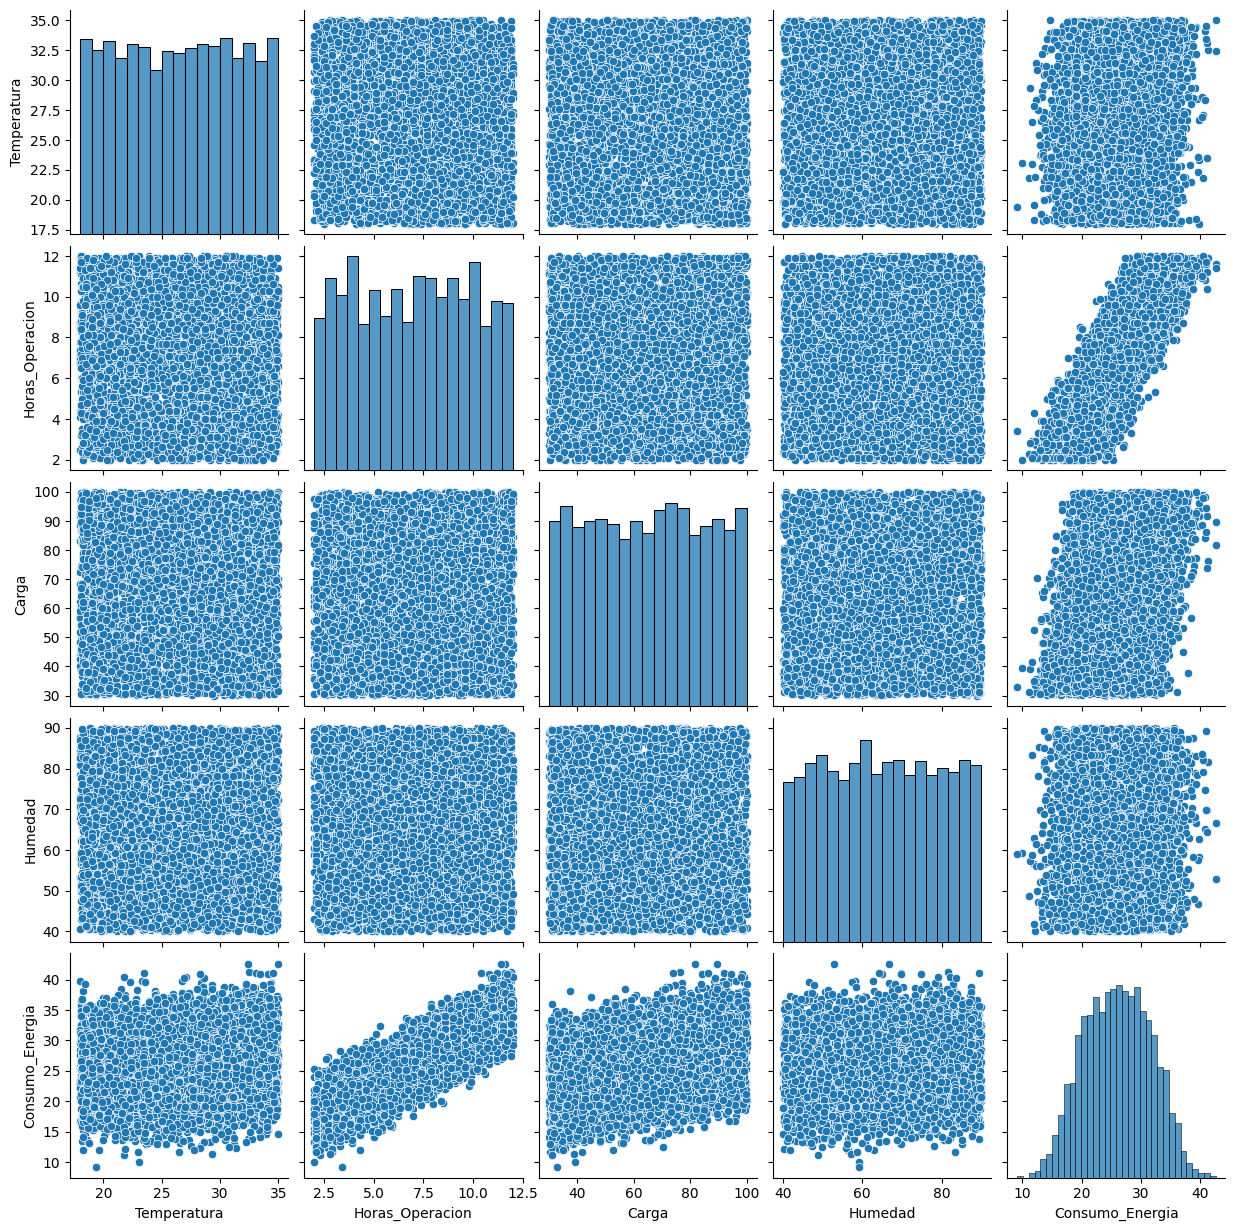

In [ ]:
sns.pairplot(df)

'\nUna gráfica very bonita\n'

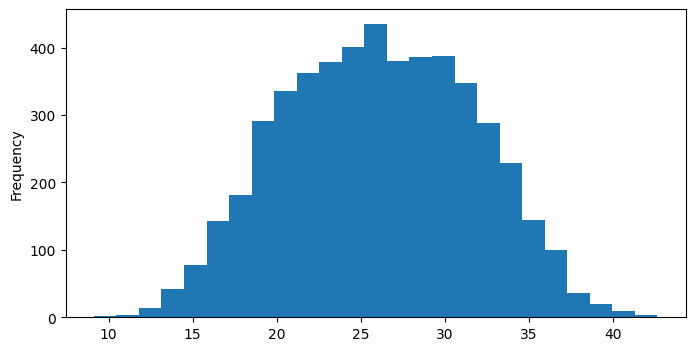

In [ ]:
df['Consumo_Energia'].plot.hist(bins=25, figsize=(8,4))
'''
Una gráfica very bonita
'''

'\nUna gráfica sobre la densidad :P\n'

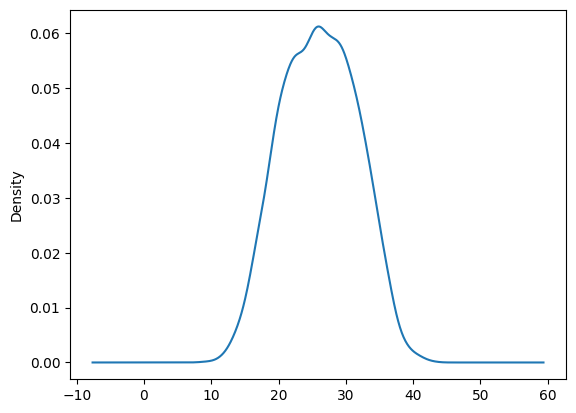

In [ ]:
df['Consumo_Energia'].plot.density()
'''
Una gráfica sobre la densidad :P
'''

In [ ]:
numeric_df=df.select_dtypes(include=[np.number])
numeric_df.corr().round(4)

,Temperatura,Horas_Operacion,Carga,Humedad,Consumo_Energia
Temperatura,1.0000,-0.0260,0.0102,0.0166,0.0978
Horas_Operacion,-0.0260,1.0000,-0.0099,0.0060,0.8434
Carga,0.0102,-0.0099,1.0000,0.0060,0.3366
Humedad,0.0166,0.0060,0.0060,1.0000,0.0627
Consumo_Energia,0.0978,0.8434,0.3366,0.0627,1.0000


'\nHoras de operación\n'

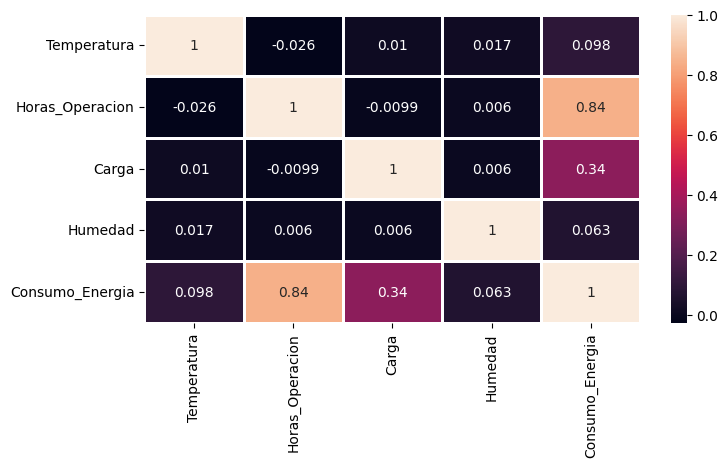

In [ ]:
plt.figure(figsize=(8,4))
sns.heatmap(numeric_df.corr(),annot=True, linewidths=2) #mapa de calor
'''
Horas de operación
'''

In [ ]:
l_column= list(df.columns) # Haciendo una lista de las columna
len_feature= len(l_column) # Longitud
l_column

['Temperatura', 'Horas_Operacion', 'Carga', 'Humedad', 'Consumo_Energia']

In [ ]:
X = df[l_column[0:len_feature-1]]
y = df[l_column[len_feature-1]]
X.head()

,Temperatura,Horas_Operacion,Carga,Humedad
0,29.8,7.4,76.4,87.0
1,22.9,4.3,88.8,74.9
2,21.9,10.4,87.7,65.7
3,27.4,7.8,55.7,79.0
4,30.2,6.9,42.3,62.9


In [ ]:
y.head()

,Consumo_Energia
0,28.97
1,21.85
2,37.43
3,26.32
4,26.08


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123
)
#

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [ ]:
lm = LinearRegression()

In [ ]:
lm.fit(X_train, y_train)

LinearRegression()

In [ ]:
print("El termino de intersección del modelo líneal:",lm.intercept_)

El termino de intersección del modelo líneal: 2.741067446117448


In [ ]:
print("Los coeficientes del modelo líneal:", lm.coef_)

Los coeficientes del modelo líneal: [0.13713677 1.66877804 0.09634816 0.02679108]


In [ ]:
cdf =pd.DataFrame(data=lm.coef_, index=X_train.columns, columns=["coeficientes"])
cdf

,coeficientes
Temperatura,0.137137
Horas_Operacion,1.668778
Carga,0.096348
Humedad,0.026791


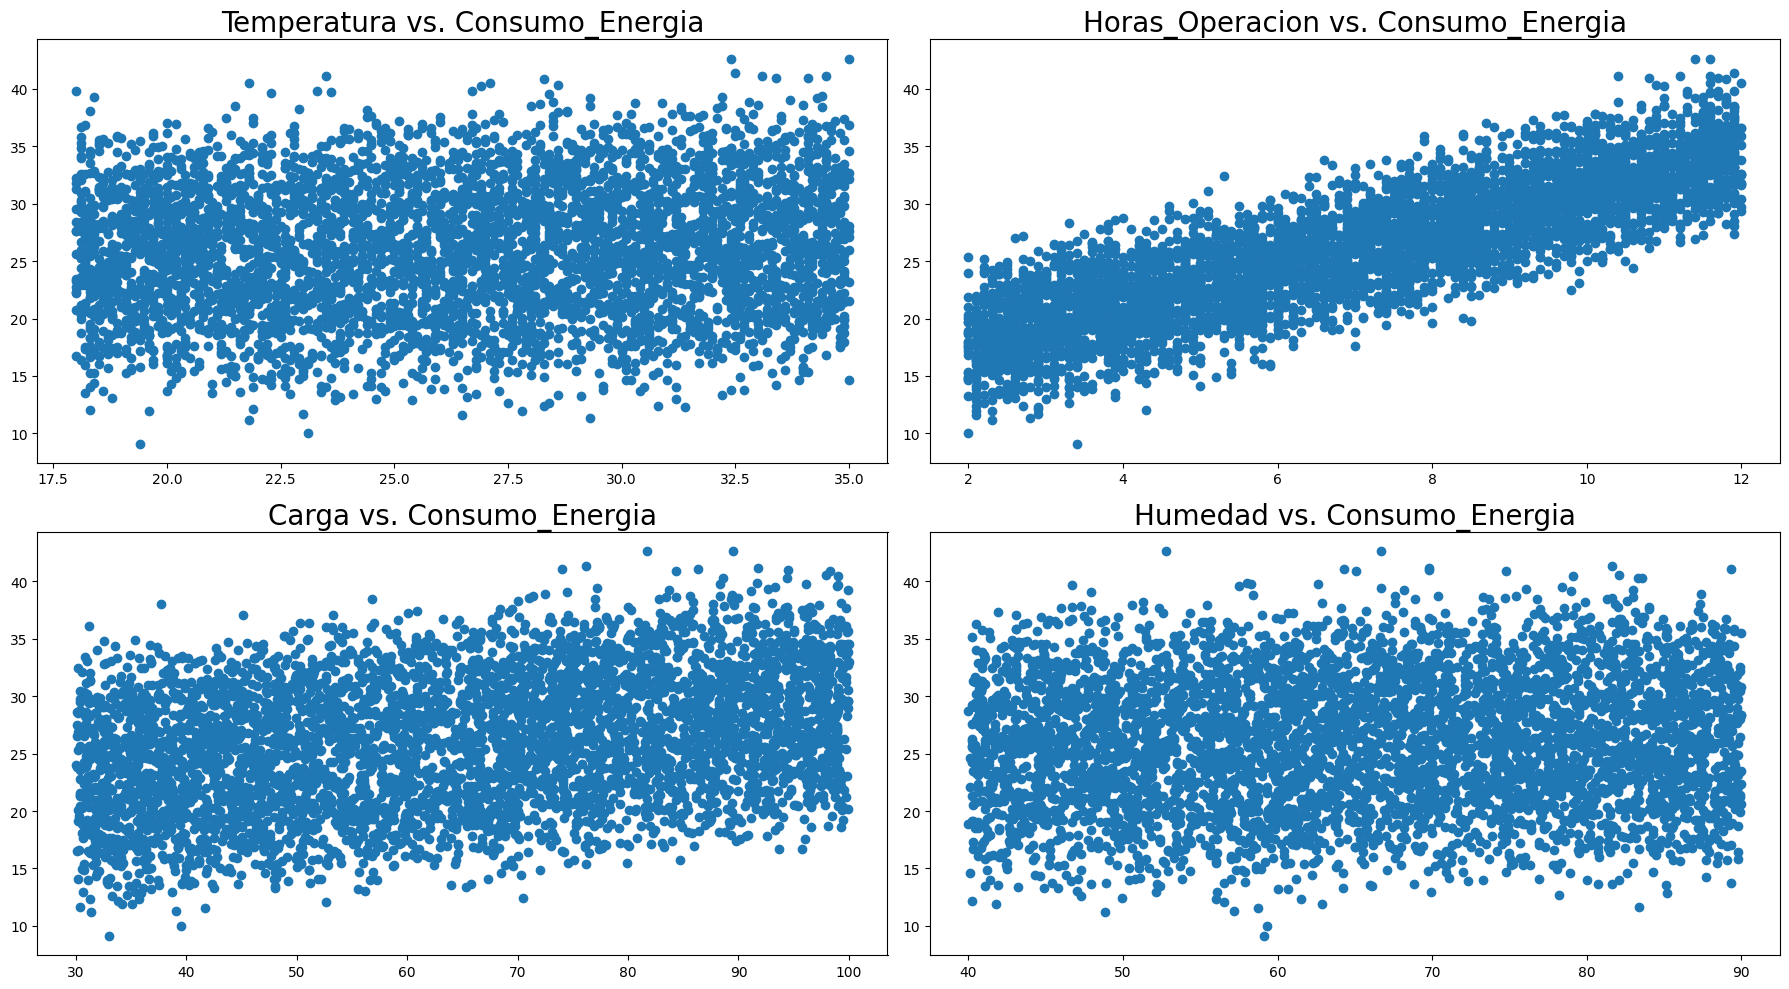

In [ ]:
from matplotlib import gridspec
l = list(cdf.index)
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 2)
for i in range(4):
    ax = plt.subplot(gs[i])
    ax.scatter(df[l[i]], df['Consumo_Energia'])
    ax.set_title(l[i] + " vs. Consumo_Energia",
        fontdict={'fontsize': 20})
plt.tight_layout()
plt.show()

Cálculo de error estandar

/tmp/ipykernel_7126/3599896422.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  r = (sum_error/dfN)
/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/tmp/ipykernel_7126/3599896422.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  r = (sum_error/dfN)
/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/tmp/ipykernel_7126/3599896422.py:11: RuntimeWarning: divide by zero encountered in scalar d

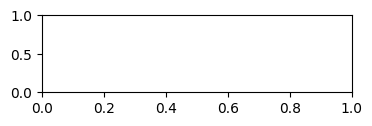

In [ ]:
n = X_train.shape[1]
k = X_train.shape[1]
dfN = n - k
train_pred=lm.predict(X_train)

train_error = np.square(train_pred - y_train)
sum_error = np.sum(train_error)

se=[0,0,0,0]
for i in range(k):
  r = (sum_error/dfN)
  r = r/np.sum(np.square(X_train[list(X_train)]))

In [ ]:
n=X_train.shape[0]
k=X_train.shape[1]
dfN = n-k
train_pred=lm.predict(X_train)

train_error = np.square(train_pred - y_train)
sum_error=np.sum(train_error)

se=[0.0]*k # Initialize with floats and correct size
for i in range(k):
  mse = (sum_error/dfN)
  # Calculate variance for the i-th coefficient using a simplified approach
  # (assuming it's a component of the standard error calculation for each feature)
  variance_coeff = mse / np.sum(np.square(X_train[X_train.columns[i]]-X_train[X_train.columns[i]].mean()))
  se[i] = np.sqrt(variance_coeff) # Store the standard error

cdf['Standard Error']=se
cdf['t-statistic']=cdf['coeficientes']/cdf['Standard Error']
cdf

,coeficientes,Standard Error,t-statistic
Temperatura,0.137137,0.007557,18.147233
Horas_Operacion,1.668778,0.013138,127.020720
Carga,0.096348,0.001859,51.826973
Humedad,0.026791,0.002611,10.260097


In [ ]:
predictions = lm.predict(X_test)
print ("Tipo del objeto predicho :", type(predictions))
print ("Tamaño del objeto predicho:", predictions.shape)

Tipo del objeto predicho : <class 'numpy.ndarray'>
Tamaño del objeto predicho: (1500,)


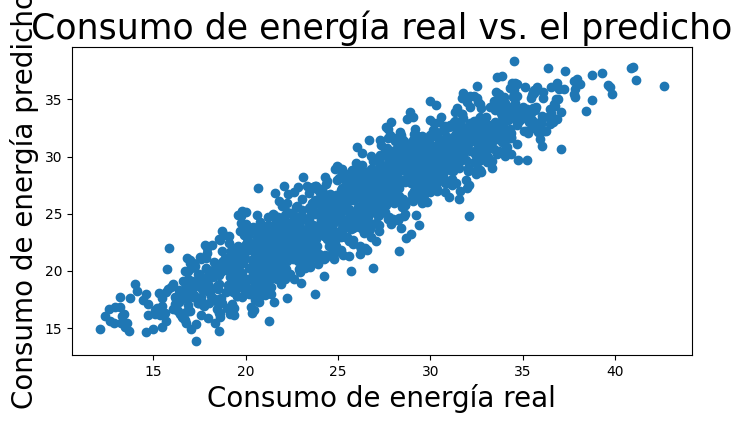

In [ ]:
'''
Meta: Dato caen em una línea recta de 45°
'''
plt.figure(figsize=(8,4))
plt.title("Consumo de energía real vs. el predicho", fontsize=25)
plt.xlabel("Consumo de energía real", fontsize=20)
plt.ylabel("Consumo de energía predicho", fontsize=20)
plt.scatter(x=y_test, y=predictions)

/tmp/ipykernel_7126/3427077418.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot([y_test-predictions])


<Axes: title={'center': 'Histograma de residuos para verificar la normalidad'}, xlabel='Residuos', ylabel='Densidad de kernel'>

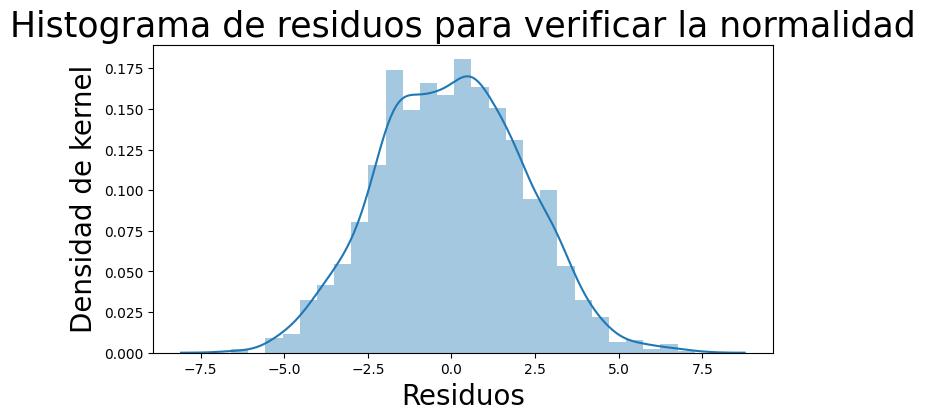

In [ ]:
plt.figure(figsize=(8,4))
plt.title("Histograma de residuos para verificar la normalidad", fontsize=25)
plt.xlabel("Residuos", fontsize=20)
plt.ylabel("Densidad de kernel", fontsize=20)
sns.distplot([y_test-predictions])

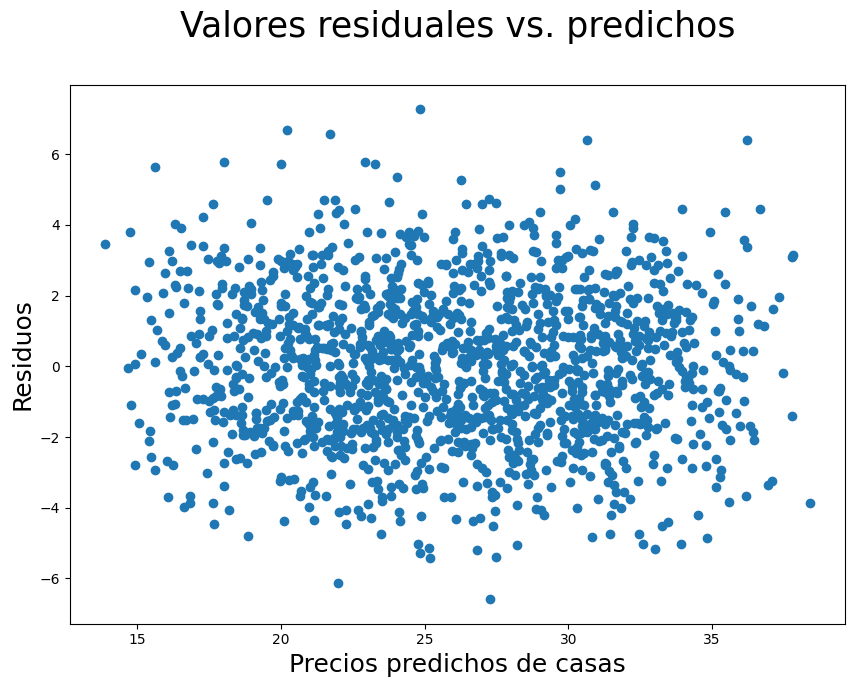

In [ ]:
'''
La variable de los erroes es aprox. constante a lo largo de las predicciones
'''
plt.figure(figsize=(10,7))
plt.title("Valores residuales vs. predichos\n",fontsize=25)
plt.xlabel("Precios predichos de casas",fontsize=18)
plt.ylabel("Residuos", fontsize=18)
plt.scatter(x=predictions,y=y_test-predictions)

In [ ]:
from sklearn.datasets import make_regression

In [ ]:
n_samples= 100
n_features = 6
n_infomativo = 3

In [ ]:
X, y, coef = make_regression(n_samples=n_samples, n_features=n_features, n_informative=n_infomativo, random_state=20, shuffle = False, noise =20, coef =True)
print(coef)

[78.58638696 97.72361019 52.30606265  0.          0.          0.        ]


In [ ]:
df = pd.DataFrame(data= X, columns= ['X' + str(i) for i in range(1, n_features +1 )])
df1= pd.DataFrame(data=y, columns=['y'])
df = pd.concat([df, df1], axis=1)
df.head(10)

,X1,X2,X3,X4,X5,X6,y
0,0.883893,0.195865,0.357537,-2.343262,-1.084833,0.559696,109.512132
1,0.939469,-0.978481,0.503097,0.406414,0.323461,-0.493411,52.542242
2,-0.792017,-0.842368,-1.279503,0.245715,-0.044195,1.567633,-247.679018
3,1.051109,0.406368,-0.168646,-3.189703,1.120132,1.332778,98.678111
4,-0.243339,-0.130031,-0.109017,1.556186,0.128778,-2.066949,-55.286890
5,-0.885493,-1.104579,0.932866,2.059838,-0.934938,-1.612990,-94.821349
6,0.527070,-1.551101,0.329613,-1.136527,-0.338491,0.320971,-75.940071
7,-0.602308,1.544728,0.647034,0.593217,0.438024,1.357789,139.247064
8,1.204511,1.351796,0.493437,-2.704365,-0.555186,0.001509,246.470338
9,0.857094,1.481144,-0.219661,1.503398,-1.482385,-0.856164,204.709196


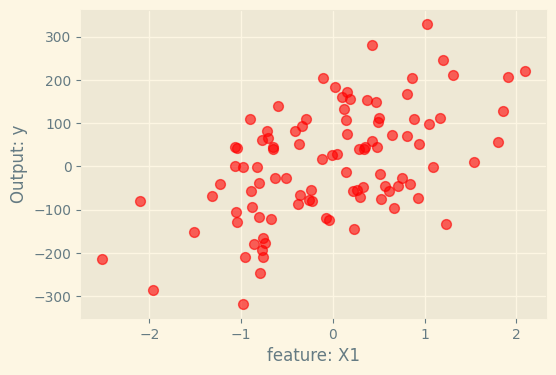

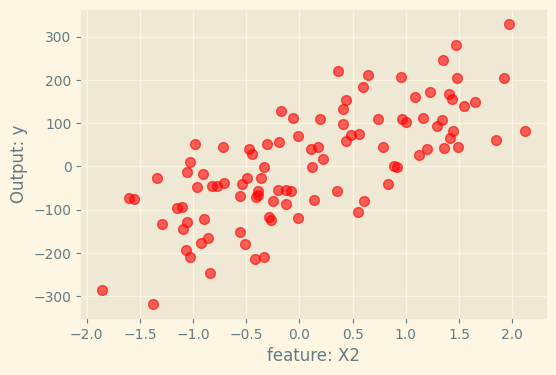

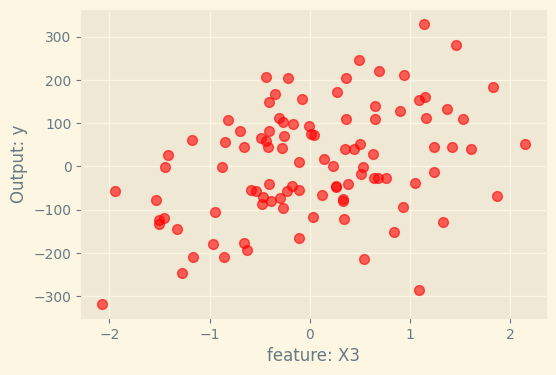

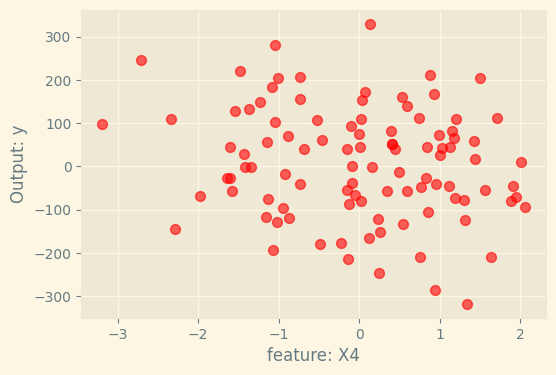

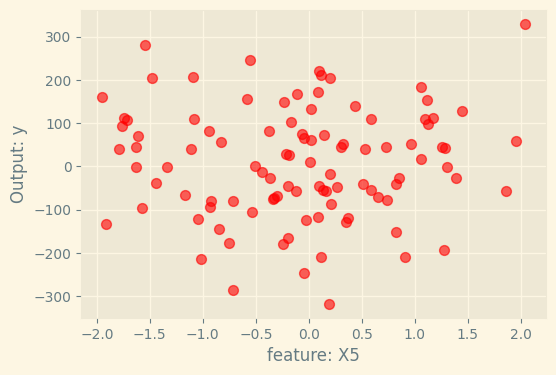

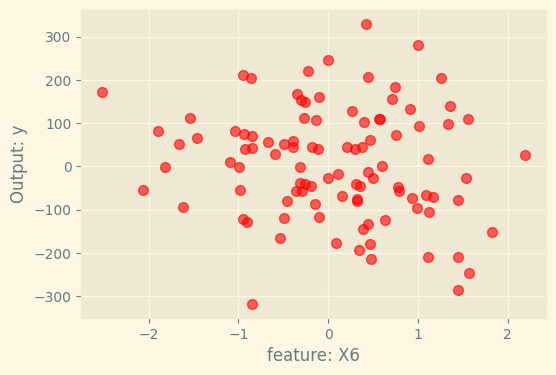

In [ ]:
with plt.style.context(('Solarize_Light2')):
  for i, col in enumerate(df.columns[:-1]):
    plt.figure(figsize=(6,4))
    plt.grid(True)
    plt.xlabel('feature: '+col, fontsize=12 )
    plt.ylabel('Output: y', fontsize=12)
    plt.scatter(df[col], df['y'], c='red', s=50, alpha=0.6)

In [ ]:
from sklearn import tree
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

In [ ]:
tree_model = tree.DecisionTreeRegressor(max_depth=5, random_state = 10)
tree_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=10)

Mean square error(MSE): 7931.574768958281


'\n¿Por qué se eleva al cuadrado?\n Para que los errores positivos y negativos no se cancelen y para penalizar más de los errores grandes.\n'

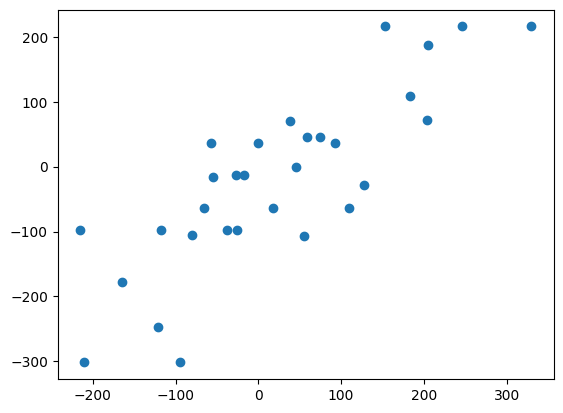

In [ ]:
from sklearn import metrics
test_pred = tree_model.predict(X_test)
plt.scatter(x=y_test, y=test_pred)
print("Mean square error(MSE):", metrics.mean_squared_error(y_test, test_pred))
'''
¿Por qué se eleva al cuadrado?
 Para que los errores positivos y negativos no se cancelen y para penalizar más de los errores grandes.
'''

Importancia relativa de las características:  [0.26900246 0.53730467 0.11075698 0.03758107 0.01219288 0.03316193]


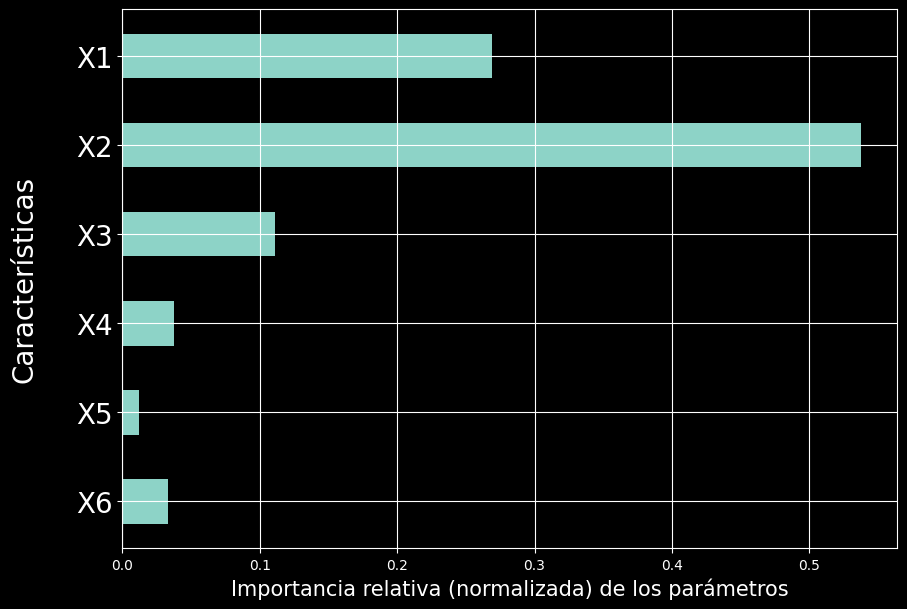

In [ ]:
print("Importancia relativa de las características: ", tree_model.feature_importances_)
with plt.style.context('dark_background'):
    plt.figure(figsize=(10, 7))
    plt.grid(True)
    plt.yticks(range(n_features + 1, 1, -1), df.columns[:-1], fontsize=20)
    plt.xlabel("Importancia relativa (normalizada) de los parámetros", fontsize=15)
    plt.ylabel("Características\n", fontsize=20)
    plt.barh(range(n_features + 1, 1, -1), width=tree_model.feature_importances_, height=0.5)

In [ ]:
import statsmodels.api as sm

In [ ]:
Xs=sm.add_constant(X)
stat_model =sm.OLS(y,Xs)
stat_result = stat_model.fit()
print(stat_result.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.976
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     628.6
Date:                Wed, 16 Sep 2026   Prob (F-statistic):           5.97e-73
Time:                        04:17:08   Log-Likelihood:                -440.25
No. Observations:                 100   AIC:                             894.5
Df Residuals:                      93   BIC:                             912.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.8565      2.087     -1.848      0.0